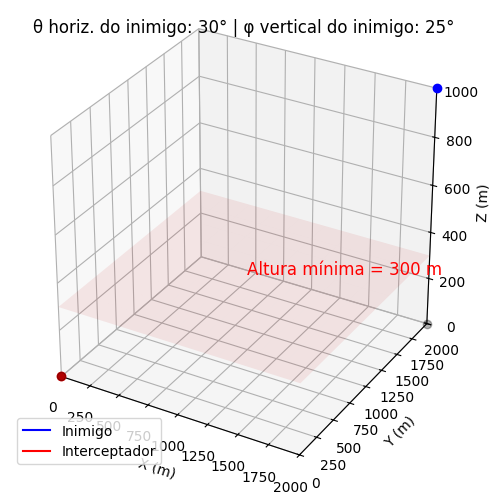

In [5]:
# Instalar dependências (Colab)
!pip install -q cvxpy pillow

import numpy as np
import matplotlib.pyplot as plt
import matplotlib.animation as animation
import cvxpy as cp
from mpl_toolkits.mplot3d import Axes3D
from matplotlib.animation import PillowWriter
from IPython.display import HTML, display

# ------------------------
# Parâmetros
# ------------------------
g = 9.8
dt = 0.1
N = 80
t_vals = np.arange(N) * dt

h_min = 300  # metros
a_max = 100 # Increased from 50 to 100

X_MAX = 2000
Y_MAX = 2000
Z_MAX = 1000

# ------------------------
# ÂNGULOS CONTROLADOS
# ------------------------
theta_deg = 30
phi_deg   = 25
speed = 120

theta = np.deg2rad(theta_deg)
phi   = np.deg2rad(phi_deg)

# ------------------------
# Míssil inimigo
# ------------------------
x0_e, y0_e, z0_e = X_MAX, Y_MAX, Z_MAX

vx_e = -speed * np.cos(phi) * np.cos(theta)
vy_e = -speed * np.cos(phi) * np.sin(theta)
vz_e = -speed * np.sin(phi)

x_e = x0_e + vx_e * t_vals
y_e = y0_e + vy_e * t_vals
z_e = z0_e + vz_e * t_vals - 0.5 * g * t_vals**2

# ------------------------
# Interceptação
# ------------------------
valid_idxs = np.where(z_e >= h_min)[0]
if len(valid_idxs) == 0:
    raise ValueError("Sem interceptação válida.")
k_hit = valid_idxs[-1]

# ------------------------
# CVXPY
# ------------------------
x = cp.Variable(N)
y = cp.Variable(N)
z = cp.Variable(N)

vx = cp.Variable(N)
vy = cp.Variable(N)
vz = cp.Variable(N)

ax = cp.Variable(N-1)
ay = cp.Variable(N-1)
az = cp.Variable(N-1)

constraints = [
    x[0] == 0, y[0] == 0, z[0] == 0,
    vx[0] == 0, vy[0] == 0, vz[0] == 0,
]

for k in range(N-1):
    constraints += [
        x[k+1] == x[k] + vx[k]*dt + 0.5*ax[k]*dt**2,
        y[k+1] == y[k] + vy[k]*dt + 0.5*ay[k]*dt**2,
        z[k+1] == z[k] + vz[k]*dt + 0.5*(az[k] - g)*dt**2,

        vx[k+1] == vx[k] + ax[k]*dt,
        vy[k+1] == vy[k] + ay[k]*dt,
        vz[k+1] == vz[k] + (az[k] - g)*dt,

        cp.abs(ax[k]) <= a_max,
        cp.abs(ay[k]) <= a_max,
        cp.abs(az[k]) <= a_max,
    ]

constraints += [
    x[k_hit] == x_e[k_hit],
    y[k_hit] == y_e[k_hit],
    z[k_hit] == z_e[k_hit],
    z[k_hit] >= h_min
]

objective = cp.Minimize(
    cp.sum_squares(ax) + cp.sum_squares(ay) + cp.sum_squares(az)
)

prob = cp.Problem(objective, constraints)
prob.solve()

# Check if the problem was solved successfully
if prob.status not in [cp.OPTIMAL, cp.OPTIMAL_INACCURATE]:
    raise ValueError(f"CVXPY problem did not solve to optimality. Status: {prob.status}")

x_d, y_d, z_d = x.value, y.value, z.value

# ------------------------
# Animação 3D
# ------------------------
fig = plt.figure(figsize=(8,6))
ax3d = fig.add_subplot(111, projection='3d')

ax3d.set_xlim(0, X_MAX)
ax3d.set_ylim(0, Y_MAX)
ax3d.set_zlim(0, Z_MAX)
ax3d.set_box_aspect([1,1,1])

ax3d.set_xlabel("X (m)")
ax3d.set_ylabel("Y (m)")
ax3d.set_zlabel("Z (m)")

# texto dos ângulos
ax3d.text2D(
    0.05, 0.95,
    f"θ horiz. do inimigo: {theta_deg}° | φ vertical do inimigo: {phi_deg}°",
    transform=ax3d.transAxes,
    fontsize=12
)

# plano altura mínima
xx, yy = np.meshgrid(
    np.linspace(0, X_MAX, 10),
    np.linspace(0, Y_MAX, 10)
)
zz = h_min * np.ones_like(xx)

ax3d.plot_surface(xx, yy, zz, alpha=0.08, color='red')

ax3d.text(
    X_MAX*0.5, Y_MAX*0.5, h_min + 30,
    f"Altura mínima = {h_min} m",
    fontsize=12,
    color='red'
)

# trajetórias
linha_e, = ax3d.plot([], [], [], 'b-', label='Inimigo')
linha_d, = ax3d.plot([], [], [], 'r-', label='Interceptador')

ponto_e, = ax3d.plot([], [], [], 'bo')
ponto_d, = ax3d.plot([], [], [], 'ro')

# sombra (ponto)
shadow_e, = ax3d.plot([], [], [], 'ko', alpha=0.3)
shadow_d, = ax3d.plot([], [], [], 'ko', alpha=0.3)

# 💥 explosão (invisível no início)
explosion, = ax3d.plot([], [], [], 'yo', markersize=20)
explosion.set_visible(False)

ax3d.legend()

def animate(i):
    if i >= N:
        i = N - 1

    if i < k_hit:
        linha_e.set_data(x_e[:i], y_e[:i])
        linha_e.set_3d_properties(z_e[:i])

        linha_d.set_data(x_d[:i], y_d[:i])
        linha_d.set_3d_properties(z_d[:i])

        ponto_e.set_data([x_e[i]], [y_e[i]])
        ponto_e.set_3d_properties([z_e[i]])

        ponto_d.set_data([x_d[i]], [y_d[i]])
        ponto_d.set_3d_properties([z_d[i]])

        shadow_e.set_data([x_e[i]], [y_e[i]])
        shadow_e.set_3d_properties([0])

        shadow_d.set_data([x_d[i]], [y_d[i]])
        shadow_d.set_3d_properties([0])

    else:
        linha_e.set_data([], [])
        linha_d.set_data([], [])

    # 💥 explosão animada correta
    if k_hit <= i < k_hit + 10:
        explosion.set_visible(True)

        size = 20 + (i - k_hit) * 10
        alpha = 1 - (i - k_hit)/10

        explosion.set_markersize(size)
        explosion.set_alpha(alpha)

        explosion.set_data([x_e[k_hit]], [y_e[k_hit]])
        explosion.set_3d_properties([z_e[k_hit]])
    else:
        explosion.set_visible(False)

    return (linha_e, linha_d, ponto_e, ponto_d,
            shadow_e, shadow_d, explosion)

ani = animation.FuncAnimation(fig, animate, frames=N, interval=80, blit=False)

# mostrar no notebook(comentado pq github nao aceita javascript)
#display(HTML(ani.to_jshtml()))
#plt.close(fig)

# ------------------------
# SALVAR COMO GIF
# ------------------------
ani.save("interceptacao.gif", writer=PillowWriter(fps=15))

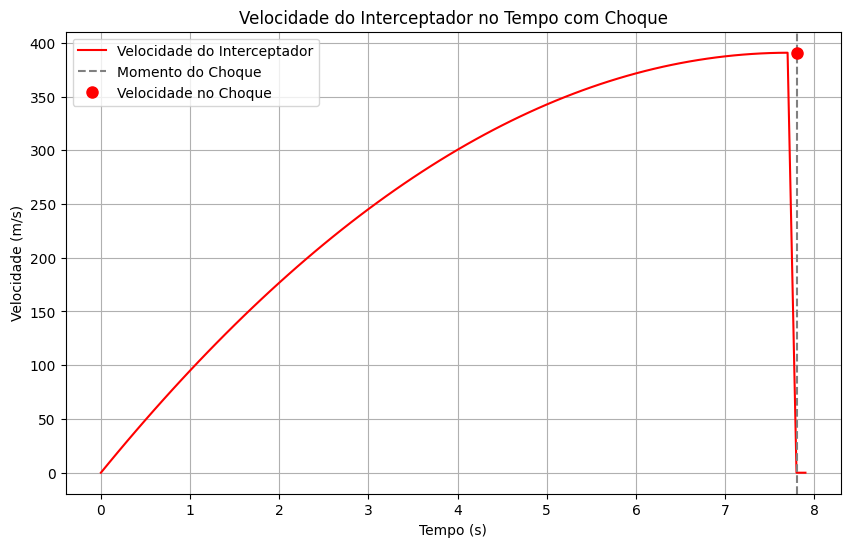

In [4]:
velocidade_interceptador = np.sqrt(vx.value**2 + vy.value**2 + vz.value**2)

# Simular a velocidade caindo para zero no momento do choque
velocidade_interceptador_plot = np.copy(velocidade_interceptador)
velocidade_interceptador_plot[k_hit:] = 0

plt.figure(figsize=(10, 6))
plt.plot(t_vals, velocidade_interceptador_plot, 'r-', label='Velocidade do Interceptador')

# Marcar o momento do choque
plt.axvline(t_vals[k_hit], color='gray', linestyle='--', label='Momento do Choque')
plt.plot(t_vals[k_hit], velocidade_interceptador[k_hit], 'ro', markersize=8, label='Velocidade no Choque')

plt.title('Velocidade do Interceptador no Tempo com Choque')
plt.xlabel('Tempo (s)')
plt.ylabel('Velocidade (m/s)')
plt.grid(True)
plt.legend()
plt.show()

In [ ]:
from matplotlib.animation import PillowWriter

ani.save("interceptacao.gif", writer=PillowWriter(fps=15))